In [17]:
import numpy as np
import pandas as pd
import torch
import transformers


from datasets import load_from_disk

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    EarlyStoppingCallback,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

In [18]:
MODEL_NAME = "jhu-clsp/mmBERT-small"

DATASET_PATH = "hf-dataset-3class-full"

MAX_LENGTH = 512
RANDOM_STATE = 17

In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [4]:
!git clone https://github.com/HassanHijaze/Data.git

Cloning into 'Data'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 30 (delta 0), reused 0 (delta 0), pack-reused 28 (from 1)
Receiving objects: 100% (30/30), 47.85 MiB | 19.80 MiB/s, done.
Resolving deltas: 100% (7/7), done.


In [5]:
cd Data

/content/Data


In [9]:
dataset = load_from_disk(
    DATASET_PATH
)

dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'file', 'text', 'label', 'language', 'split', 'source', 'source_name', 'source_type', 'document_type', 'title', 'document_id', 'target_length', 'actual_word_count', 'character_count', 'original_document_length', 'publication_date', 'date_basis', 'retrieval_date', 'license_name', 'license_url', 'source_url', 'hash', 'generator_provider', 'generator_model', 'seed_sample_id'],
        num_rows: 24986
    })
    validation: Dataset({
        features: ['id', 'file', 'text', 'label', 'language', 'split', 'source', 'source_name', 'source_type', 'document_type', 'title', 'document_id', 'target_length', 'actual_word_count', 'character_count', 'original_document_length', 'publication_date', 'date_basis', 'retrieval_date', 'license_name', 'license_url', 'source_url', 'hash', 'generator_provider', 'generator_model', 'seed_sample_id'],
        num_rows: 2906
    })
    test: Dataset({
        features: ['id', 'file', 'text', 'label', 'lan

config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/46.4k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.5MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

In [11]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

In [12]:
columns_to_remove = [
    column
    for column in dataset["train"].column_names
    if column != "label"
]

tokenized_dataset = dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=columns_to_remove,
    desc="Tokenizing dataset",
)

Tokenizing dataset:   0%|          | 0/24986 [00:00<?, ? examples/s]

Tokenizing dataset:   0%|          | 0/2906 [00:00<?, ? examples/s]

Tokenizing dataset:   0%|          | 0/2737 [00:00<?, ? examples/s]

In [13]:
from transformers import DataCollatorWithPadding
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    pad_to_multiple_of=8 if torch.cuda.is_available() else None,
)

In [14]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,

    id2label={
        0: "HUMAN",
        1: "AI",
        2: "AI_ASSISTED",
    },

    label2id={
        "HUMAN": 0,
        "AI": 1,
        "AI_ASSISTED": 2,
    },
)

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  564MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: jhu-clsp/mmBERT-small
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
decoder.weight    | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
use_bf16 = (
    torch.cuda.is_available()
    and torch.cuda.is_bf16_supported()
)

print("BF16:", use_bf16)

BF16: True


In [19]:
training_args = TrainingArguments(
    output_dir="checkpoints-mmbert-small",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    num_train_epochs=5,

    weight_decay=0.01,
    warmup_steps=235,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_strategy="steps",
    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    save_total_limit=2,

    bf16=use_bf16,
    fp16=torch.cuda.is_available() and not use_bf16,

    report_to="none",

    seed=RANDOM_STATE,
    data_seed=RANDOM_STATE,
)

In [20]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_from_disk

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)

In [21]:
import numpy as np
from sklearn.metrics import accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=1,
    )

    return {
        "accuracy": accuracy_score(
            labels,
            predictions,
        )
    }

In [22]:
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],

    processing_class=tokenizer,
    data_collator=data_collator,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=1
        )
    ],
)

In [23]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.263775,0.329522,0.911218
2,0.175610,0.221671,0.956986
3,0.120112,0.298976,0.954233


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [24]:
validation_output = trainer.predict(
    tokenized_dataset["validation"]
)

validation_logits = np.asarray(
    validation_output.predictions
)

y_validation = np.asarray(
    dataset["validation"]["label"],
    dtype=np.int64,
)


def fit_temperature(logits, labels):

    logits_tensor = torch.tensor(
        logits,
        dtype=torch.float64,
    )

    labels_tensor = torch.tensor(
        labels,
        dtype=torch.long,
    )

    log_temperature = torch.nn.Parameter(
        torch.zeros(
            (),
            dtype=torch.float64,
        )
    )

    criterion = torch.nn.CrossEntropyLoss()

    optimizer = torch.optim.LBFGS(
        [log_temperature],
        lr=0.1,
        max_iter=50,
        line_search_fn="strong_wolfe",
    )

    def closure():
        optimizer.zero_grad()

        temperature = log_temperature.exp()

        loss = criterion(
            logits_tensor / temperature,
            labels_tensor,
        )

        loss.backward()

        return loss

    optimizer.step(closure)

    return float(
        log_temperature.exp().detach()
    )


def probabilities_from_logits(
    logits,
    temperature=1.0,
):

    scaled_logits = (
        np.asarray(
            logits,
            dtype=np.float64,
        )
        / temperature
    )

    scaled_logits -= scaled_logits.max(
        axis=1,
        keepdims=True,
    )

    exponentiated = np.exp(
        scaled_logits
    )

    return (
        exponentiated
        / exponentiated.sum(
            axis=1,
            keepdims=True,
        )
    )


MMBERT_TEMPERATURE = fit_temperature(
    validation_logits,
    y_validation,
)

print(
    f"Learned mmBERT temperature: "
    f"{MMBERT_TEMPERATURE:.4f}"
)

Learned mmBERT temperature: 2.7918


In [25]:
from sklearn.metrics import log_loss
import numpy as np
import pandas as pd


def multiclass_brier_score(y_true, probabilities, n_classes=3):

    y_onehot = np.eye(n_classes)[y_true]

    return np.mean(
        np.sum(
            (probabilities - y_onehot) ** 2,
            axis=1,
        )
    )


uncalibrated_validation_probabilities = probabilities_from_logits(
    validation_logits
)

calibrated_validation_probabilities = probabilities_from_logits(
    validation_logits,
    MMBERT_TEMPERATURE,
)


calibration_comparison = pd.DataFrame(
    [
        {
            "model": "Uncalibrated",

            "Brier score": multiclass_brier_score(
                y_validation,
                uncalibrated_validation_probabilities,
            ),

            "Log loss": log_loss(
                y_validation,
                uncalibrated_validation_probabilities,
                labels=[0, 1, 2],
            ),
        },

        {
            "model": "Temperature-scaled",

            "Brier score": multiclass_brier_score(
                y_validation,
                calibrated_validation_probabilities,
            ),

            "Log loss": log_loss(
                y_validation,
                calibrated_validation_probabilities,
                labels=[0, 1, 2],
            ),
        },
    ]
).set_index("model")


calibration_comparison.style.format(
    "{:.4f}"
)

,Brier score,Log loss
model,,
Uncalibrated,0.0735,0.2217
Temperature-scaled,0.0655,0.1215


In [26]:
split_logits = {
    "validation": validation_logits
}

for split_name in ("train", "test"):
    prediction_output = trainer.predict(
        tokenized_dataset[split_name]
    )

    split_logits[split_name] = np.asarray(
        prediction_output.predictions
    )


def multiclass_brier_score(
    y_true,
    probabilities,
    n_classes=3,
):
    y_onehot = np.eye(n_classes)[y_true]

    return np.mean(
        np.sum(
            (probabilities - y_onehot) ** 2,
            axis=1,
        )
    )


def evaluate_split(split_name):

    y_true = np.asarray(
        dataset[split_name]["label"],
        dtype=np.int64,
    )

    probabilities = probabilities_from_logits(
        split_logits[split_name],
        MMBERT_TEMPERATURE,
    )

    y_pred = np.argmax(
        probabilities,
        axis=1,
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1, 2],
    )

    return {
        "split": split_name,

        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),

        "brier_score": multiclass_brier_score(
            y_true,
            probabilities,
        ),

        "log_loss": log_loss(
            y_true,
            probabilities,
            labels=[0, 1, 2],
        ),

        "confusion_matrix": cm,
    }


evaluation = pd.DataFrame(
    [
        evaluate_split("train"),
        evaluate_split("validation"),
        evaluate_split("test"),
    ]
).set_index("split")


evaluation.style.format(
    {
        "accuracy": "{:.2%}",
        "brier_score": "{:.4f}",
        "log_loss": "{:.4f}",
    }
)

,accuracy,brier_score,log_loss,confusion_matrix
split,,,,
train,98.82%,0.0183,0.0440,[[8260 1 81] [ 5 8301 18] [ 178 11 8131]]
validation,95.70%,0.0655,0.1215,[[925 0 46] [ 4 951 12] [ 52 11 905]]
test,95.65%,0.0690,0.1246,[[873 1 40] [ 2 899 11] [ 53 12 846]]


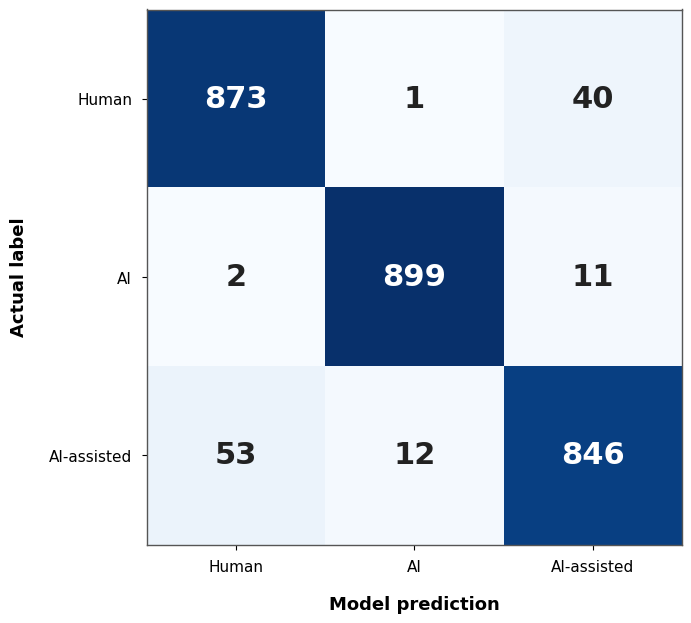

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

y_test = np.asarray(
    dataset["test"]["label"],
    dtype=np.int64,
)

test_probabilities = probabilities_from_logits(
    split_logits["test"],
    MMBERT_TEMPERATURE,
)

y_test_pred = np.argmax(
    test_probabilities,
    axis=1,
)

test_matrix = confusion_matrix(
    y_test,
    y_test_pred,
    labels=[0, 1, 2],
)

class_names = [
    "Human",
    "AI",
    "AI-assisted",
]

fig, ax = plt.subplots(figsize=(7, 7))

ax.imshow(
    test_matrix,
    cmap="Blues",
    vmin=0,
    vmax=test_matrix.max(),
)

for row in range(3):
    for column in range(3):

        value = test_matrix[row, column]

        text_color = (
            "white"
            if value > test_matrix.max() / 2
            else "#222222"
        )

        ax.text(
            column,
            row,
            f"{value:,}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=22,
            fontweight="bold",
        )

ax.set_xticks(
    [0, 1, 2],
    labels=class_names,
)

ax.set_yticks(
    [0, 1, 2],
    labels=class_names,
)

ax.set_xlabel(
    "Model prediction",
    fontsize=13,
    fontweight="bold",
    labelpad=15,
)

ax.set_ylabel(
    "Actual label",
    fontsize=13,
    fontweight="bold",
    labelpad=15,
)

ax.tick_params(
    axis="both",
    labelsize=11,
    pad=7,
)

for spine in ax.spines.values():
    spine.set_color("#555555")
    spine.set_linewidth(1)

fig.tight_layout()

plt.savefig(
    "mmbert-confmat-3class.svg"
)

plt.show()

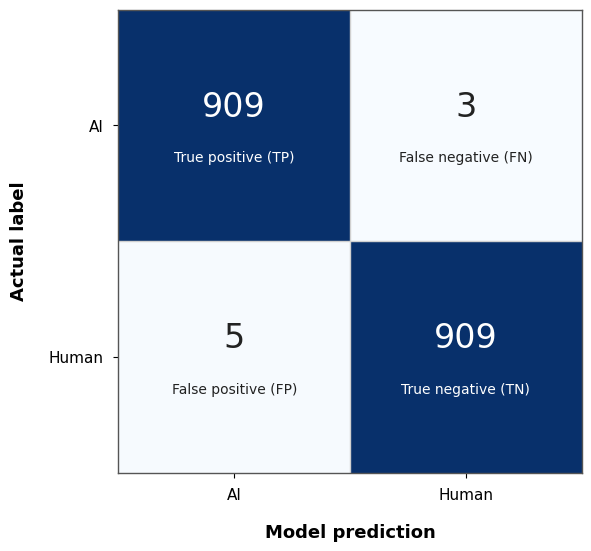

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Keep only Human (0) and AI (1)
y_test_all = np.asarray(
    dataset["test"]["label"],
    dtype=np.int64,
)

mask = y_test_all != 2

y_test = y_test_all[mask]

test_logits_binary = split_logits["test"][mask]

# Apply mmBERT temperature scaling
test_probabilities = probabilities_from_logits(
    test_logits_binary,
    MMBERT_TEMPERATURE,
)

# Keep only Human and AI probabilities
human_prob = test_probabilities[:, 0]
ai_prob = test_probabilities[:, 1]

# Renormalize because AI-assisted is removed
total = human_prob + ai_prob

human_prob = human_prob / total
ai_prob = ai_prob / total

# Binary prediction
y_test_pred = (
    ai_prob >= 0.5
).astype(np.int64)

# AI first, then Human
test_matrix = confusion_matrix(
    y_test,
    y_test_pred,
    labels=[1, 0],
)

cell_labels = np.asarray(
    [
        ["True positive (TP)", "False negative (FN)"],
        ["False positive (FP)", "True negative (TN)"],
    ]
)

fig, ax = plt.subplots(
    figsize=(6, 6)
)

ax.imshow(
    test_matrix,
    cmap="Blues",
    vmin=0,
    vmax=test_matrix.max(),
)

for row in range(2):
    for column in range(2):

        value = test_matrix[
            row,
            column
        ]

        text_color = (
            "white"
            if value > test_matrix.max() / 2
            else "#222222"
        )

        ax.text(
            column,
            row - 0.08,
            f"{value:,}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=24,
        )

        ax.text(
            column,
            row + 0.14,
            cell_labels[row, column],
            ha="center",
            va="center",
            color=text_color,
            fontsize=10,
        )

ax.set_xticks(
    [0, 1],
    labels=["AI", "Human"],
)

ax.set_yticks(
    [0, 1],
    labels=["AI", "Human"],
)

ax.set_xlabel(
    "Model prediction",
    fontsize=13,
    fontweight="bold",
    labelpad=15,
)

ax.set_ylabel(
    "Actual label",
    fontsize=13,
    fontweight="bold",
    labelpad=15,
)

ax.axhline(
    0.5,
    color="#d0d0d0",
    linewidth=1,
)

ax.axvline(
    0.5,
    color="#d0d0d0",
    linewidth=1,
)

ax.tick_params(
    axis="both",
    labelsize=11,
    pad=7,
)

for spine in ax.spines.values():
    spine.set_color("#555555")
    spine.set_linewidth(1)

fig.tight_layout()

plt.savefig(
    "mmbert-confmat-human-ai.svg"
)

plt.show()

In [29]:
label_names = {
    0: "Human",
    1: "AI",
    2: "AI-assisted",
}

y_test = np.asarray(
    dataset["test"]["label"],
    dtype=np.int64,
)

test_probabilities = probabilities_from_logits(
    split_logits["test"],
    MMBERT_TEMPERATURE,
)

y_test_pred = np.argmax(
    test_probabilities,
    axis=1,
)

prediction_confidence = np.max(
    test_probabilities,
    axis=1,
)

test_errors = pd.DataFrame(
    {
        "id": dataset["test"]["id"],

        "actual": [
            label_names[label]
            for label in y_test
        ],

        "prediction": [
            label_names[label]
            for label in y_test_pred
        ],

        "prediction_confidence": prediction_confidence,

        "human_probability": test_probabilities[:, 0],
        "ai_probability": test_probabilities[:, 1],
        "ai_assisted_probability": test_probabilities[:, 2],

        "source_name": dataset["test"]["source_name"],

        "generator_model": dataset["test"]["generator_model"],

        "text": [
            text[:300]
            for text in dataset["test"]["text"]
        ],
    }
)

# Keep only mistakes
test_errors = test_errors[
    test_errors["actual"]
    != test_errors["prediction"]
].copy()

test_errors.sort_values(
    "prediction_confidence",
    ascending=False,
).head(20).style.format(
    {
        "prediction_confidence": "{:.2%}",
        "human_probability": "{:.2%}",
        "ai_probability": "{:.2%}",
        "ai_assisted_probability": "{:.2%}",
    }
)

,id,actual,prediction,prediction_confidence,human_probability,ai_probability,ai_assisted_probability,source_name,generator_model,text
1855,20857,AI-assisted,AI,99.46%,0.01%,99.46%,0.53%,peDOCS (DIPF),gpt-5.6-luna,"Die Verteilungen der meisten imputierten Variablen stimmen weitgehend mit den beobachteten Werten überein. Eine Ausnahme bildet die Verteilung des Kriteriums: In den vollständigen Datensätzen beträgt die Studienabbruchquote 25,6 Prozent und liegt damit in einer ähnlichen Größenordnung wie die in and"
1645,18518,AI,AI-assisted,99.36%,0.16%,0.48%,99.36%,SSOAR,gpt-6-luna,"An der FernUniversität in Hagen widmet sich das Lehrgebiet Multimedia und Internetanwendungen seit Langem der dauerhaften Sicherung digitaler Daten. Ein Schwerpunkt liegt darauf, Daten mit ergänzenden Informationen auszustatten, damit sie auch künftig sinnvoll weiterverwendet werden können. Darüber"
1224,13840,AI,AI-assisted,99.21%,0.03%,0.76%,99.21%,SSOAR,gemini,Im Feld internationaler Konfliktbearbeitung nehmen die Vereinten Nationen weiterhin eine herausragende Vermittlungsrolle ein: Keine andere internationale Organisation tritt so häufig als Mediatorin in zwischenstaatlichen und innerstaatlichen Konflikten auf (Bercovitch & Schneider 2000: 156; Greig &
2342,26294,AI-assisted,Human,97.59%,97.59%,0.14%,2.26%,peDOCS (DIPF),deepseek-flash,"Es wird eine der wesentlichen Aufgaben der kommenden Zeit sein, sich mit diesem Spannungsverhältnis, mit dieser Ambiguität (Zweiseitigkeit/Doppelwertigkeit) auseinanderzusetzen. Katja Rohde und Fredi Saal sind Zeugen einer persönlichen Lebensdeutung, welche die »Selbstwahrnehmung« zumindest als eben"
607,6923,Human,AI-assisted,97.53%,2.47%,0.01%,97.53%,peDOCS (DIPF),None,"Überträgt man dieses Verständnis auf den Begriff der Widersprüche, lassen sich hieraus sowohl ein erfahrener Widerspruch als auch ein handelnder Widerspruch skizzieren: „Zum einen kann ein Widerspruch demnach ein gegensätzlicher Sachverhalt sein, den man erfährt. Zum anderen kann ein Widerspruch auß"
2420,27246,AI-assisted,Human,97.51%,97.51%,0.08%,2.40%,peDOCS (DIPF),deepseek-flash,"Auch wenn die Kinder- und Jugendhilfe, die Wohnungslosen- und Drogenhilfe und viele andere Felder heute vor allem beruflich erbrachte Handlungsfelder sind und dadurch ein hohes Maß an Verlässlichkeit und fachlicher Expertise im Handeln erreicht haben, wird die Soziale Arbeit in fast allen ihren Feld"
2309,25798,AI-assisted,Human,97.22%,97.22%,0.09%,2.68%,peDOCS (DIPF),deepseek-flash,"Dieser Effekt erscheint plausibel, da im vorangegangenen Bachelorstudium studienrelevante Kompetenzen erworben wurden. Für die Aufnahme eines Studiums fordern die meisten Hochschulen den Nachweis von Sprachkenntnissen in Deutsch und/oder Englisch. Daher wurde der Frage nachgegangen, ob Studierende m"
2408,27107,AI-assisted,Human,97.09%,97.09%,0.12%,2.78%,peDOCS (DIPF),deepseek-flash,"Daher ist zu vermuten, dass auch Geschlecht auf je unterschiedliche Weise (re)produziert wird. Damit folgen wir der von Engler formulierten These eines Wechselverhältnisses von sozialen Feldern und der Kategorie Geschlecht: „Geschlecht als Dimension des Sozialen durch die Vermittlung der Felder zum"
230,2755,Human,AI-assisted,96.95%,2.52%,0.53%,96.95%,SSOAR,None,"Die Anteile der Anhänger des Systems und der entschiedenen Gegner schwankten in dieser Zeitspanne jeweils zwischen 20 und 30 Prozent. Dabei umfasste die Kerngruppe der überzeugten Parteigänger zwischen 5 und 10 Prozent. Erst im Jahr 1989, als sich die Legitimationsschwäche des Regimes verstärkte, na"
2367,26607,AI-assisted,Human,96.95%,96.95%,0.21%,2.84%,peDOCS (DIPF),deepseek-flash,"Wir deuten dies nicht als Unregelmäßigkeit in der Form der Datenerhebung, sondern verstehen es im Sinne von all is data als Ausdruck eines spezifischen, auch kollektiv-familiären Umgangs mit der Pandemiesituation. Mit den beiden Bildstrecken und den Familieninterviews stehen sich zwei gegenläufige S"


In [30]:
from pathlib import Path
from importlib.metadata import version
import platform
import json
import numpy as np

from sklearn.metrics import accuracy_score


# ============================================================
# ARTIFACT DIRECTORY
# ============================================================

ARTIFACT_DIR = Path("artifacts") / "mmbert-small-3class"

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# SAVE MODEL + TOKENIZER
# ============================================================

trainer.save_model(
    ARTIFACT_DIR
)

tokenizer.save_pretrained(
    ARTIFACT_DIR
)


# ============================================================
# VALIDATION ACCURACY
# ============================================================

validation_predictions = np.argmax(
    validation_logits,
    axis=1,
)

best_validation_accuracy = accuracy_score(
    y_validation,
    validation_predictions,
)


# ============================================================
# METADATA
# ============================================================

metadata = {
    "dataset": "hf-dataset-3class-full",

    "base_model": MODEL_NAME,

    "label_mapping": {
        "human": 0,
        "ai": 1,
        "ai_assisted": 2,
    },

    "max_length": MAX_LENGTH,

    "calibration": "temperature scaling",

    "temperature": float(
        MMBERT_TEMPERATURE
    ),

    "best_validation_accuracy": float(
        best_validation_accuracy
    ),

    "best_checkpoint": (
        trainer.state.best_model_checkpoint
    ),

    "random_state": RANDOM_STATE,

    "python_version": platform.python_version(),

    "package_versions": {
        package: version(package)
        for package in [
            "datasets",
            "numpy",
            "scikit-learn",
            "torch",
            "transformers",
        ]
    },
}


# ============================================================
# SAVE METADATA
# ============================================================

METADATA_PATH = (
    ARTIFACT_DIR
    / "detector-config.json"
)

METADATA_PATH.write_text(
    json.dumps(
        metadata,
        indent=2,
    ) + "\n",
    encoding="utf-8",
)


# ============================================================
# OUTPUT
# ============================================================

print(
    f"Saved model and tokenizer to: "
    f"{ARTIFACT_DIR}"
)

print(
    f"Saved detector configuration to: "
    f"{METADATA_PATH}"
)

print(
    f"Validation accuracy: "
    f"{best_validation_accuracy:.2%}"
)

print(
    f"Temperature: "
    f"{MMBERT_TEMPERATURE:.4f}"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model and tokenizer to: artifacts/mmbert-small-3class
Saved detector configuration to: artifacts/mmbert-small-3class/detector-config.json
Validation accuracy: 95.70%
Temperature: 2.7918


In [31]:
from pathlib import Path
import json
import torch
import numpy as np

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)


# ============================================================
# MMBERT ARTIFACT PATH
# ============================================================

ARTIFACT_DIR = Path("artifacts") / "mmbert-small-3class"

METADATA_PATH = (
    ARTIFACT_DIR
    / "detector-config.json"
)


# ============================================================
# LOAD MODEL + TOKENIZER + CONFIG
# ============================================================

loaded_tokenizer = AutoTokenizer.from_pretrained(
    ARTIFACT_DIR
)

loaded_model = AutoModelForSequenceClassification.from_pretrained(
    ARTIFACT_DIR
)

loaded_config = json.loads(
    METADATA_PATH.read_text(
        encoding="utf-8"
    )
)


# ============================================================
# DEVICE
# ============================================================

if torch.cuda.is_available():
    inference_device = torch.device("cuda")

elif (
    hasattr(torch.backends, "mps")
    and torch.backends.mps.is_available()
):
    inference_device = torch.device("mps")

else:
    inference_device = torch.device("cpu")


print("Device:", inference_device)


loaded_model.to(
    inference_device
)

loaded_model.eval()


# ============================================================
# PREDICTION FUNCTION
# ============================================================

def predict_probabilities(texts):

    inputs = loaded_tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=loaded_config["max_length"],
        return_tensors="pt",
    )

    inputs = {
        key: value.to(inference_device)
        for key, value in inputs.items()
    }

    with torch.inference_mode():

        logits = loaded_model(
            **inputs
        ).logits

        calibrated_logits = (
            logits
            / loaded_config["temperature"]
        )

        probabilities = torch.softmax(
            calibrated_logits,
            dim=1,
        )

    return probabilities.cpu().numpy()


# ============================================================
# LABELS
# ============================================================

id2label = {
    0: "Human",
    1: "AI",
    2: "AI-assisted",
}


# ============================================================
# EXAMPLE
# ============================================================

texts = [
    """
    Die fortschreitende Digitalisierung von Entscheidungsprozessen in Verwaltung und Politik wird häufig als neutraler Rationalisierungsschritt dargestellt. Diese Sichtweise verkennt jedoch den normativen Charakter technologischer Systeme. Algorithmen und datengestützte Modelle sind keine objektiv reflektierenden Instrumente; sie begründen sich stets auf spezifischen Prämissen, Datenselektionen und Zielvorgaben ihrer Entwickler. Wenn komplexe gesellschaftliche Zielkonflikte rein technokratisch behandelt werden, droht eine Entpolitisierung essenzieller Debatten. Technische Systeme können zwar Effizienz steigern und Informationsgrundlagen strukturieren, sie ersetzen jedoch weder die ethische Folgenabschätzung noch die demokratische Legitimation. Eine nachhaltige gesellschaftliche Transformation erfordert daher, die Systemarchitekturen kontinuierlich an rechtsstaatlichen Werten und sozialer Verantwortung zu messen, anstatt politische Ermessensspielräume an automatisierte Prozesse abzutreten.
    """
]


probabilities = predict_probabilities(
    texts
)


for text, probs in zip(
    texts,
    probabilities,
):

    prediction = int(
        np.argmax(probs)
    )

    label = id2label[
        prediction
    ]

    print(
        f"Prediction: {label}"
    )

    print(
        f"Human:       {probs[0]:.1%}"
    )

    print(
        f"AI:          {probs[1]:.1%}"
    )

    print(
        f"AI-assisted: {probs[2]:.1%}"
    )

    print(
        f"\n{text}"
    )

Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

Device: cuda
Prediction: AI
Human:       0.0%
AI:          100.0%
AI-assisted: 0.0%


    Die fortschreitende Digitalisierung von Entscheidungsprozessen in Verwaltung und Politik wird häufig als neutraler Rationalisierungsschritt dargestellt. Diese Sichtweise verkennt jedoch den normativen Charakter technologischer Systeme. Algorithmen und datengestützte Modelle sind keine objektiv reflektierenden Instrumente; sie begründen sich stets auf spezifischen Prämissen, Datenselektionen und Zielvorgaben ihrer Entwickler. Wenn komplexe gesellschaftliche Zielkonflikte rein technokratisch behandelt werden, droht eine Entpolitisierung essenzieller Debatten. Technische Systeme können zwar Effizienz steigern und Informationsgrundlagen strukturieren, sie ersetzen jedoch weder die ethische Folgenabschätzung noch die demokratische Legitimation. Eine nachhaltige gesellschaftliche Transformation erfordert daher, die Systemarchitekturen kontinuierlich an rechtsstaatlichen Werten und sozialer Verantwortung

NameError: name 'MMBERT_BASE_TEMPERATURE' is not defined